In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
import torchvision.utils as vutils
import shutil
import glob


In [2]:
base_dir = "/data-science-bowl-2018"  # Change if needed
train_img_dir = "/Users/akshaj/Desktop/Research Project/data-science-bowl-2018/stage1_train"

output_dir = os.path.join("./gan_output")

real_dir = os.path.join(output_dir, "real")
fake_dir = os.path.join(output_dir, "fake")
os.makedirs(real_dir, exist_ok=True)
os.makedirs(fake_dir, exist_ok=True)


In [3]:
from torch.utils.data import Dataset
from PIL import Image
import os

class NucleiDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.transform = transform
        for folder in os.listdir(root_dir):
            img_dir = os.path.join(root_dir, folder, "images")
            if not os.path.isdir(img_dir):
                continue
            for file in os.listdir(img_dir):
                if file.endswith(".png"):
                    self.image_paths.append(os.path.join(img_dir, file))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("L")  # Grayscale, not RGB
        if self.transform:
            image = self.transform(image)
        return image

train_img_dir = "/Users/akshaj/Desktop/Research Project/data-science-bowl-2018/stage1_train"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = NucleiDataset(train_img_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Loaded {len(dataset)} valid training images.")


Loaded 670 valid training images.


In [4]:
class Generator(nn.Module):
    def __init__(self, z_dim, img_channels=1, features_g=64):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # Input: [B, z_dim, 1, 1]
            nn.ConvTranspose2d(z_dim, features_g * 8, 8, 1, 0),  # [B, 512, 8, 8]
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1),  # [B, 256, 16, 16]
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1),  # [B, 128, 32, 32]
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1),  # [B, 64, 64, 64]
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g, img_channels, 4, 2, 1),  # [B, 1, 128, 128]
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


class Discriminator(nn.Module):
    def __init__(self, img_channels=1, features_d=64):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # Input: [B, 1, 128, 128]
            nn.Conv2d(img_channels, features_d, 4, 2, 1),  # [B, 64, 64, 64]
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d, features_d * 2, 4, 2, 1),  # [B, 128, 32, 32]
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1),  # [B, 256, 16, 16]
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1),  # [B, 512, 8, 8]
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 8, 1, 8),  # [B, 1, 1, 1]
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)  # Flatten to shape [B]



In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z_dim = 100  # Standard latent dimension size

G = Generator(z_dim=z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizerD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

z_dim = 100
fixed_noise = torch.randn(64, z_dim, 1, 1, device=device)


In [6]:
num_epochs = 1000
G_losses, D_losses = [], []

for epoch in range(num_epochs):
    for real_imgs in dataloader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Train Discriminator
        D.zero_grad()
        labels_real = torch.ones(batch_size, device=device)
        output_real = D(real_imgs)
        lossD_real = criterion(output_real, labels_real)

        noise = torch.randn(batch_size, z_dim, 1, 1, device=device)
        fake_imgs = G(noise)
        labels_fake = torch.zeros(batch_size, device=device)
        output_fake = D(fake_imgs.detach())
        lossD_fake = criterion(output_fake, labels_fake)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # Train Generator
        G.zero_grad()
        output_fake = D(fake_imgs)
        lossG = criterion(output_fake, labels_real)
        lossG.backward()
        optimizerG.step()

    G_losses.append(lossG.item())
    D_losses.append(lossD.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{num_epochs} | Loss D: {lossD:.4f} | Loss G: {lossG:.4f}")


Epoch 0/1000 | Loss D: 0.0205 | Loss G: 7.0724
Epoch 50/1000 | Loss D: 0.0000 | Loss G: 10.6105
Epoch 100/1000 | Loss D: 0.3889 | Loss G: 4.3092
Epoch 150/1000 | Loss D: 0.7180 | Loss G: 4.1317
Epoch 200/1000 | Loss D: 1.6321 | Loss G: 1.0422
Epoch 250/1000 | Loss D: 0.3176 | Loss G: 4.5142
Epoch 300/1000 | Loss D: 0.2428 | Loss G: 1.5156
Epoch 350/1000 | Loss D: 3.6965 | Loss G: 7.4172
Epoch 400/1000 | Loss D: 0.6653 | Loss G: 2.4928
Epoch 450/1000 | Loss D: 0.7623 | Loss G: 4.4975
Epoch 500/1000 | Loss D: 0.8351 | Loss G: 2.4543
Epoch 550/1000 | Loss D: 0.1609 | Loss G: 4.6110
Epoch 600/1000 | Loss D: 0.1522 | Loss G: 3.4849
Epoch 650/1000 | Loss D: 0.1238 | Loss G: 4.4812
Epoch 700/1000 | Loss D: 0.4837 | Loss G: 6.7971
Epoch 750/1000 | Loss D: 0.0899 | Loss G: 5.8110
Epoch 800/1000 | Loss D: 0.0102 | Loss G: 6.3378
Epoch 850/1000 | Loss D: 0.0275 | Loss G: 5.9175
Epoch 900/1000 | Loss D: 0.0539 | Loss G: 5.4629
Epoch 950/1000 | Loss D: 0.1874 | Loss G: 4.5763


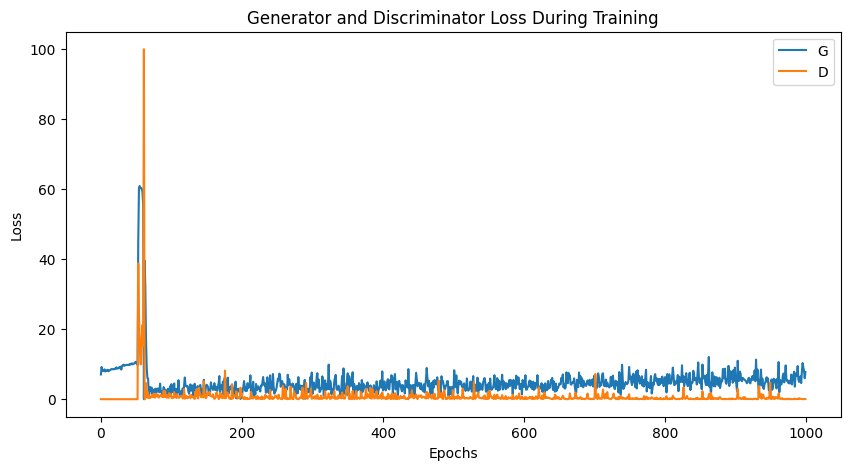

In [7]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [8]:
# Save some fake images
G.eval()
with torch.no_grad():
    fake_images = G(fixed_noise).detach().cpu()
    for i, img in enumerate(fake_images):
        img_pil = transforms.ToPILImage()(img)
        img_pil.save(f"{fake_dir}/fake_{i}.png")

# Save some real images for FID evaluation
for i, real_img in enumerate(dataloader):
    if i >= 64:
        break
    img = real_img[0]
    img_pil = transforms.ToPILImage()(img)
    img_pil.save(f"{real_dir}/real_{i}.png")


In [8]:
import os
import numpy as np
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from pytorch_fid import fid_score
import torch

def evaluate_generated_images(real_dir, fake_dir):
    print("🧪 Running SSIM and FID evaluation...")

    real_files = sorted([f for f in os.listdir(real_dir) if f.endswith('.png')])
    fake_files = sorted([f for f in os.listdir(fake_dir) if f.endswith('.png')])

    ssim_scores = []
    for r, f in zip(real_files, fake_files):
        real = np.array(Image.open(os.path.join(real_dir, r)).convert("L").resize((512, 512))) / 255.0
        fake = np.array(Image.open(os.path.join(fake_dir, f)).convert("L").resize((512, 512))) / 255.0

        # Ensure same dimensions
        if real.shape == fake.shape:
            s = ssim(real, fake, data_range=1.0)
            ssim_scores.append(s)

    print(f"🧠 Average SSIM: {np.mean(ssim_scores):.4f}")

    fid_value = fid_score.calculate_fid_given_paths(
        [real_dir, fake_dir],
        batch_size=4,
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        dims=2048
    )
    print(f"📉 FID Score: {fid_value:.2f}")

# Run this after training
evaluate_generated_images("./Results/kaggle_nuclei/1000_epoch/real", "./Results/kaggle_nuclei/1000_epoch/fake")


🧪 Running SSIM and FID evaluation...
🧠 Average SSIM: 0.4234


100%|██████████| 16/16 [00:12<00:00,  1.25it/s]


📉 FID Score: 264.01
